In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# ==========================================
# FUNGSI BANTUAN (TRAINING & EVALUASI)
# ==========================================
def train_evaluate(X, y, title):
    # Split Data (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Inisialisasi Model Decision Tree
    model = DecisionTreeClassifier(criterion='entropy', random_state=42)
    
    # Latih Model
    model.fit(X_train, y_train)
    
    # Prediksi
    y_pred = model.predict(X_test)
    
    # Evaluasi
    acc = accuracy_score(y_test, y_pred)
    
    # --- OUTPUT SESUAI REQUEST ---
    print(f"--- HASIL MODEL: {title} ---")
    print(f"Akurasi: {acc * 100:.2f}%")
    print("Classification Report:")
    # zero_division=0 agar tidak error jika ada kelas yang tidak terprediksi sama sekali
    print(classification_report(y_test, y_pred, zero_division=0))
    
    return model, acc, X_test, y_test, y_pred

In [3]:
# ==========================================
# SKENARIO 2: MENGGUNAKAN DATA BERSIH 
# ==========================================
try:
    # Load data yang sudah kita bersihkan & buang fitur lemahnya
    df_clean = pd.read_csv('../data/glass_normalized.csv')
    
    # Target ada di kolom terakhir (Target_Encoded)
    target_col_clean = df_clean.columns[-1]
    
    X_clean = df_clean.drop(target_col_clean, axis=1)
    y_clean = df_clean[target_col_clean]
    
    # Jalankan Training
    model_clean, acc_clean, X_test_clean, y_test_clean, y_pred_clean = train_evaluate(X_clean, y_clean, "DATA BERSIH")

except Exception as e:
    print(f"Gagal memproses data bersih: {e}")
    acc_clean = 0

--- HASIL MODEL: DATA BERSIH ---
Akurasi: 79.07%
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.90      0.82        10
           1       0.77      0.67      0.71        15
           2       0.40      0.67      0.50         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      0.78      0.88         9

    accuracy                           0.79        43
   macro avg       0.82      0.84      0.82        43
weighted avg       0.82      0.79      0.80        43



In [4]:
# ==========================================
# SKENARIO 1: MENGGUNAKAN DATA MENTAH
# ==========================================
try:
    # Load data mentah asli
    # Pastikan nama file sesuai dengan file awal kamu (misal glass.csv)
    df_raw = pd.read_csv('../data/glass.csv') 
    
    # Cek nama kolom target di data mentah (biasanya 'Type' atau 'label')
    # Kita cari kolom target otomatis (biasanya kolom terakhir)
    target_col_raw = df_raw.columns[-1]
    
    # Pisahkan X dan y (Tanpa preprocessing aneh-aneh)
    X_raw = df_raw.drop(target_col_raw, axis=1)
    y_raw = df_raw[target_col_raw]
    
    # Jalankan Training
    model_raw, acc_raw, X_test_raw, y_test_raw, y_pred_raw = train_evaluate(X_raw, y_raw, "DATA MENTAH")

except Exception as e:
    print(f"Gagal memproses data mentah: {e}")
    acc_raw = 0

--- HASIL MODEL: DATA MENTAH ---
Akurasi: 76.74%
Classification Report:
              precision    recall  f1-score   support

           A       0.67      0.91      0.77        11
           B       0.89      0.57      0.70        14
           C       0.67      0.67      0.67         3
           E       1.00      0.75      0.86         4
           F       0.50      0.67      0.57         3
           G       0.89      1.00      0.94         8

    accuracy                           0.77        43
   macro avg       0.77      0.76      0.75        43
weighted avg       0.80      0.77      0.76        43



In [5]:
# ==========================================
# PERBANDINGAN AKHIR
# ==========================================
print(f"1. Akurasi Data Mentah (9 Fitur) : {acc_raw * 100:.2f}%")
print(f"2. Akurasi Data Bersih (7 Fitur) : {acc_clean * 100:.2f}%")

diff = acc_clean - acc_raw
if diff > 0:
    print(f"KESIMPULAN: Hebat! Dengan membuang fitur sampah (Ca, K), akurasi NAIK {diff*100:.2f}%!")
elif diff == 0:
    print("ℹKESIMPULAN: Akurasi setara. Ini bagus, artinya kita berhasil meringankan model (hapus 2 fitur) tanpa mengurangi kepintarannya.")
else:
    print("KESIMPULAN: Akurasi turun sedikit. Mungkin fitur yang dibuang ternyata masih dibutuhkan untuk kasus edge-case tertentu.")

1. Akurasi Data Mentah (9 Fitur) : 76.74%
2. Akurasi Data Bersih (7 Fitur) : 79.07%
KESIMPULAN: Hebat! Dengan membuang fitur sampah (Ca, K), akurasi NAIK 2.33%!


In [6]:
# ==========================================
# PERBANDINGAN AKHIR
# ==========================================

print(f"1. Akurasi Data Mentah (9 Fitur) : {acc_raw * 100:.2f}%")
print(f"2. Akurasi Data Bersih (7 Fitur) : {acc_clean * 100:.2f}%")

diff = acc_clean - acc_raw
if diff > 0:
    print(f"KESIMPULAN: Hebat! Dengan membuang fitur sampah (Ca, K), akurasi NAIK {diff*100:.2f}%!")
elif diff == 0:
    print("ℹKESIMPULAN: Akurasi setara. Ini bagus, artinya kita berhasil meringankan model (hapus 2 fitur) tanpa mengurangi kepintarannya.")
else:
    print("KESIMPULAN: Akurasi turun sedikit. Mungkin fitur yang dibuang ternyata masih dibutuhkan untuk kasus edge-case tertentu.")

1. Akurasi Data Mentah (9 Fitur) : 76.74%
2. Akurasi Data Bersih (7 Fitur) : 79.07%
KESIMPULAN: Hebat! Dengan membuang fitur sampah (Ca, K), akurasi NAIK 2.33%!


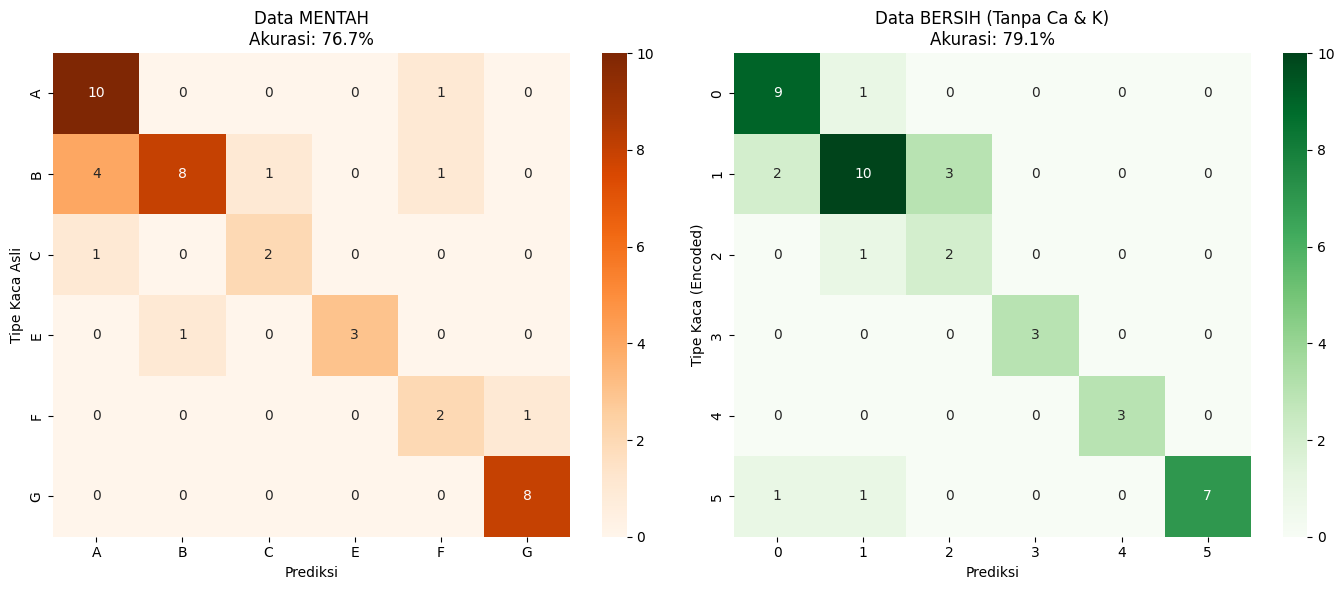

In [7]:
# ==========================================
# VISUALISASI CONFUSION MATRIX
# ==========================================
plt.figure(figsize=(14, 6))

# Plot Mentah
plt.subplot(1, 2, 1)
# Menggunakan unique labels agar matriks rapi
unique_labels_raw = sorted(y_test_raw.unique())
sns.heatmap(confusion_matrix(y_test_raw, y_pred_raw), 
            annot=True, fmt='d', cmap='Oranges',
            xticklabels=unique_labels_raw, yticklabels=unique_labels_raw)
plt.title(f'Data MENTAH\nAkurasi: {acc_raw*100:.1f}%')
plt.ylabel('Tipe Kaca Asli')
plt.xlabel('Prediksi')

# Plot Bersih
plt.subplot(1, 2, 2)
# Label encoded (0, 1, 2...)
unique_labels_clean = sorted(y_test_clean.unique())
sns.heatmap(confusion_matrix(y_test_clean, y_pred_clean), 
            annot=True, fmt='d', cmap='Greens',
            xticklabels=unique_labels_clean, yticklabels=unique_labels_clean)
plt.title(f'Data BERSIH (Tanpa Ca & K)\nAkurasi: {acc_clean*100:.1f}%')
plt.ylabel('Tipe Kaca (Encoded)')
plt.xlabel('Prediksi')

plt.tight_layout()
plt.show()

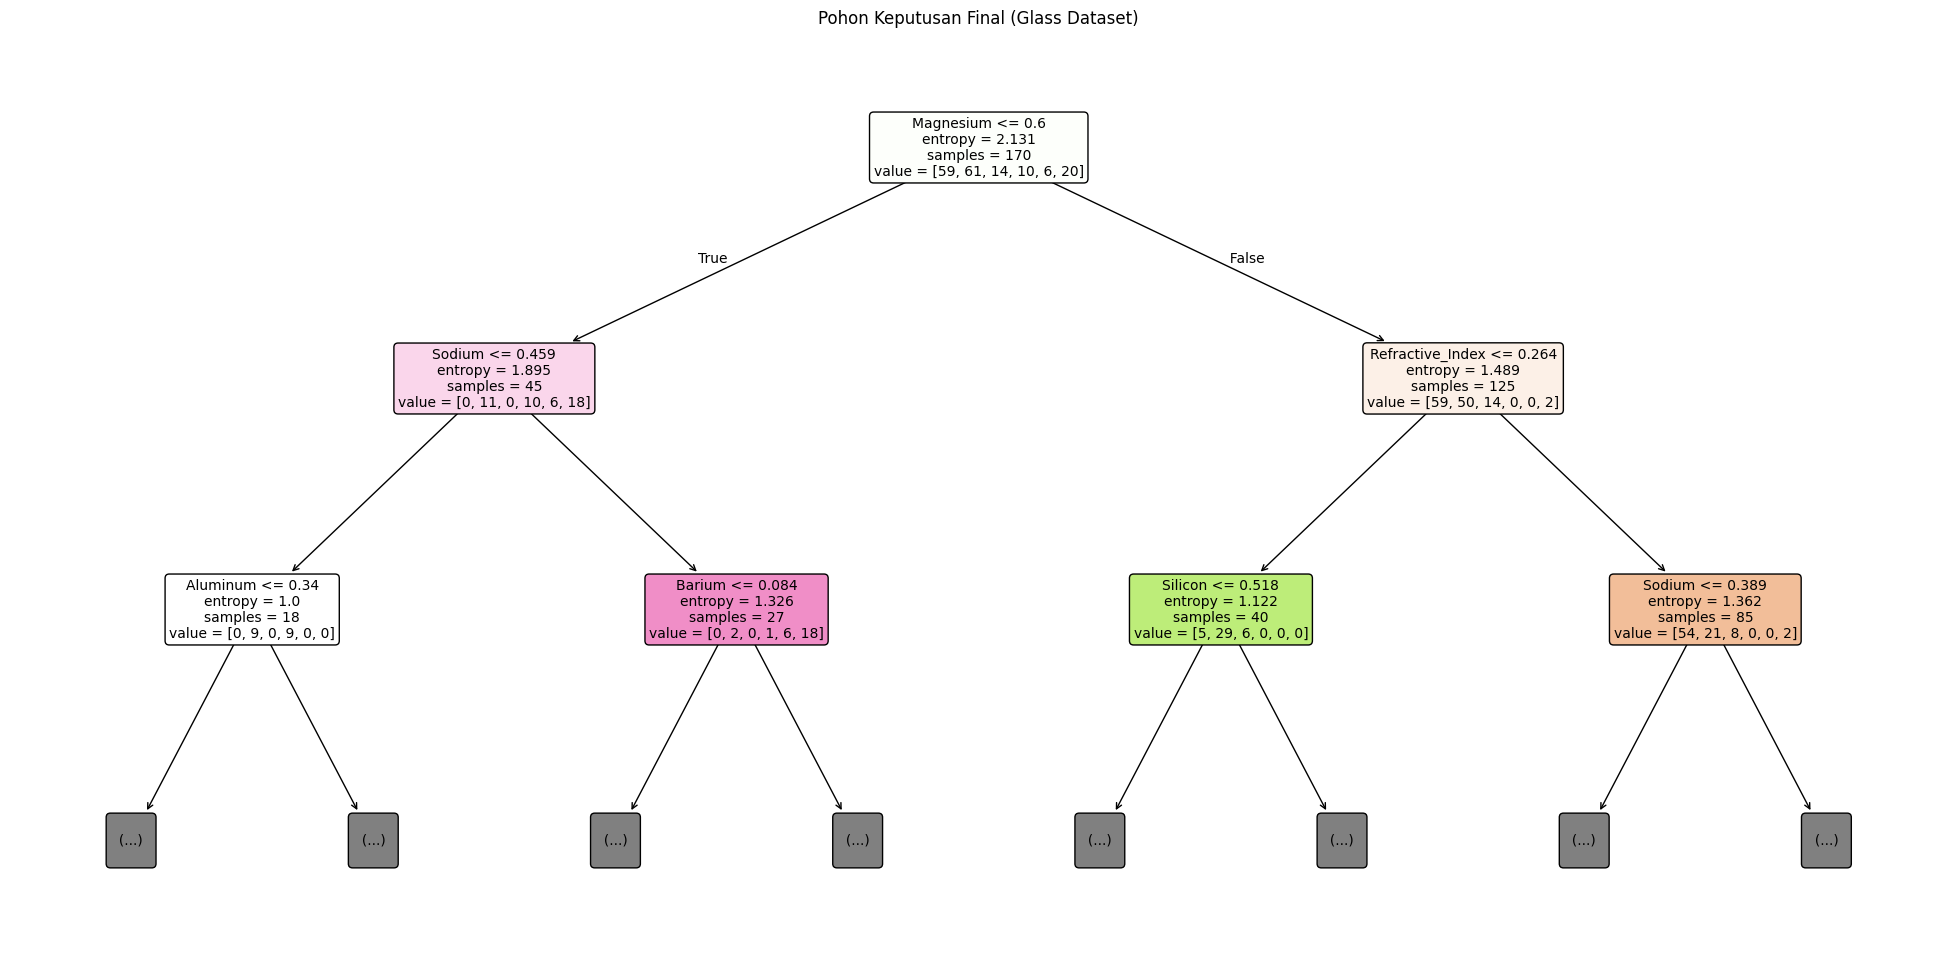

In [11]:
# ==========================================
# VISUALISASI POHON KEPUTUSAN 
# ==========================================
plt.figure(figsize=(25, 12))
plot_tree(model_clean, 
          feature_names=X_clean.columns, 
          filled=True, 
          rounded=True,
          max_depth=2,
          fontsize=10)
plt.title("Pohon Keputusan Final (Glass Dataset)")
plt.show()